<table align="left"><tr><td>
<a href="https://colab.research.google.com/github/kikim6114/nlp2026/blob/main/02.Tokenization-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="코랩에서 실행하기"/></a>
</td></tr></table>

## 반드시 Colab에서 실행할 것

<span style="font-size:2.5em">2. 텍스트 전처리 및 토큰화 (2)</span>  

이 자료는 다음 자료들을 기반으로 수정된 자료입니다.<br>
- [위키독스 딥 러닝을 이용한 자연어 처리 입문, 02. 텍스트 전처리(Text preprocessing)](https://wikidocs.net/21694)

#### 토근화 도구
- 영어 : spaCy, NLTK
- 한글 : KoNLPy

# 2.9 토큰화

### SpaCy
자연어 처리를 위한 Python 기반의 오픈 소스 라이브러리로, 다음과 같은 기능들을 제공한다.
- Tokenization
- Part-of-speech (POS) Tagging
- Depedency Parsing
- Lemmatization
- Sentence Boundary Detection (SBD)
- Named Entity Recognition (NER)
- Similarity
- Text Classification
- Rule-based Matching
- Training
- Serialization
- [spacy.io](https://spacy.io/models): spaCy를 위한 다운로드 가능한 사전훈련된 파이프라인 및 가중치

In [1]:
import sys
!{sys.executable} -m pip install spacy

In [3]:
import spacy
spacy_en = spacy.load("en_core_web_sm")  #영어 언어 모델을 로드

In [10]:
import spacy

spacy_en = spacy.load("en_core_web_sm")
text = "A Dog Run back corner near spare bedrooms."
print(spacy_en.tokenizer(text))
print([tok.text for tok in spacy_en.tokenizer(text)]) #토큰화 결과 확인

A Dog Run back corner near spare bedrooms.
['A', 'Dog', 'Run', 'back', 'corner', 'near', 'spare', 'bedrooms', '.']


위에서 `spacy.load`에서 에러 발생시, 환경에서 다음을 우선 실행하고 다시 해보자.
```
python -m spacy download en
```

### NLTK

In [8]:
import nltk
nltk.download('punkt')  #'punkt' 토크나이저 모델을 다운

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [16]:
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')  #코드 추가
word_tokenize(text)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


['A', 'Dog', 'Run', 'back', 'corner', 'near', 'spare', 'bedrooms', '.']

### 띄어쓰기 토큰화

In [17]:
text.split()

['A', 'Dog', 'Run', 'back', 'corner', 'near', 'spare', 'bedrooms.']

- 구두점만 제외하면 whitespace로 토큰화해도 충분히 쓸만 하다.

In [18]:
text = "사과의 놀라운 효능이라는 글을 봤어. 그래서 오늘 사과를 먹으려고 했는데 사과가 썩어서 슈퍼에 가서 사과랑 오렌지 사왔어."
print(text.split())

['사과의', '놀라운', '효능이라는', '글을', '봤어.', '그래서', '오늘', '사과를', '먹으려고', '했는데', '사과가', '썩어서', '슈퍼에', '가서', '사과랑', '오렌지', '사왔어.']


- '사과'가 4번 출현했는데, '-의', '-를', '-가', '-랑' 등 이 붙어 있어서 모두 다른 단어로 인식
- 한국어에서는 이를 방지하기 위해 형태소 분석기를 통해 토큰화를 수행한다.

### 한글 형태소분석기를 사용한 토큰화

In [19]:
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
%cd Mecab-ko-for-Google-Colab
!bash install_mecab-ko_on_colab_light_220429.sh
#  한국어 형태소 분석기인 '메캅(Mecab-ko)' 설치

Cloning into 'Mecab-ko-for-Google-Colab'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 138 (delta 26), reused 22 (delta 8), pack-reused 91 (from 1)
Receiving objects: 100% (138/138), 1.72 MiB | 5.65 MiB/s, done.
Resolving deltas: 100% (65/65), done.
/content/Mecab-ko-for-Google-Colab
Installing konlpy.....
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 48.8 MB/s eta 0:00:00
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2026-03-17 11:30:52--  https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
Resolving bitbucket.org (bitbucket.org)... 104.192.142.24, 104.192.142.26, 104.192.142.25, ...
Connecting to bitbucket.org (bitbucket.org)|104.192.142.24|:443... connected.
HTTP request sent, a

In [ ]:
# import sys
# !{sys.executable} -m pip install eunjeon
# !{sys.executable} -m pip install mecab-ko-dic

In [21]:
from konlpy.tag import Mecab  #Mecab / Okt / Komoran 등의 외부 형태소분석기는 KoNLPy 라이브러리를 통해 불러올 수 있음
m = Mecab()
m.pos("이것은 메캅 테스트입니다. 사용자 사전을 등록하기 전입니다. 비타500")  #형태소 단위로 분리, 품사태깅

[('이것', 'NP'),
 ('은', 'JX'),
 ('메', 'NNP'),
 ('캅', 'NNP'),
 ('테스트', 'NNG'),
 ('입니다', 'VCP+EF'),
 ('.', 'SF'),
 ('사용자', 'NNG'),
 ('사전', 'NNG'),
 ('을', 'JKO'),
 ('등록', 'NNG'),
 ('하', 'XSV'),
 ('기', 'ETN'),
 ('전', 'NNG'),
 ('입니다', 'VCP+EF'),
 ('.', 'SF'),
 ('비타', 'NNP'),
 ('500', 'SN')]

### 문자 단위 토큰화

In [23]:
text = "A Dog Run back corner near spare bedrooms."
print(list(text))

['A', ' ', 'D', 'o', 'g', ' ', 'R', 'u', 'n', ' ', 'b', 'a', 'c', 'k', ' ', 'c', 'o', 'r', 'n', 'e', 'r', ' ', 'n', 'e', 'a', 'r', ' ', 's', 'p', 'a', 'r', 'e', ' ', 'b', 'e', 'd', 'r', 'o', 'o', 'm', 's', '.']


# 2.10 어휘(Vocabulary) 생성

In [25]:
import urllib.request  #
import pandas as pd
from nltk import FreqDist  #FreqDist : 단어의 빈도 분포를 계산
import numpy as np
import matplotlib.pyplot as plt

In [26]:
urllib.request.urlretrieve('https://raw.githubusercontent.com/e9t/nsmc/master/ratings.txt',
                           filename='ratings.txt'
                           )  # 위 url에  ratings.txt 파일 다운로드
data = pd.read_table('ratings.txt')
data[:10]

,id,document,label
0,8112052,어릴때보고 지금다시봐도 재밌어요ㅋㅋ,1
1,8132799,"디자인을 배우는 학생으로, 외국디자이너와 그들이 일군 전통을 통해 발전해가는 문화산...",1
2,4655635,폴리스스토리 시리즈는 1부터 뉴까지 버릴께 하나도 없음.. 최고.,1
3,9251303,와.. 연기가 진짜 개쩔구나.. 지루할거라고 생각했는데 몰입해서 봤다.. 그래 이런...,1
4,10067386,안개 자욱한 밤하늘에 떠 있는 초승달 같은 영화.,1
5,2190435,사랑을 해본사람이라면 처음부터 끝까지 웃을수 있는영화,1
6,9279041,완전 감동입니다 다시봐도 감동,1
7,7865729,개들의 전쟁2 나오나요? 나오면 1빠로 보고 싶음,1
8,7477618,굿,1
9,9250537,바보가 아니라 병 쉰 인듯,1


In [27]:
print("전체 샘플의 수 : {}".format(len(data)))

전체 샘플의 수 : 200000


* 임의로 100개만 샘플링해서 연습

In [29]:
pd.options.mode.copy_on_write = True  # Pandas - 메모리 사용을 최적화 코드
sample_data = data[:100]

In [30]:
sample_data['document'] = sample_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","")
# 한글과 공백을 제외하고 모두  (한국어 텍스트 분석 전에 불필요한 노이즈를 제거하는 전처리 과정)
sample_data.head(10)

,id,document,label
0,8112052,어릴때보고 지금다시봐도 재밌어요ㅋㅋ,1
1,8132799,"디자인을 배우는 학생으로, 외국디자이너와 그들이 일군 전통을 통해 발전해가는 문화산...",1
2,4655635,폴리스스토리 시리즈는 1부터 뉴까지 버릴께 하나도 없음.. 최고.,1
3,9251303,와.. 연기가 진짜 개쩔구나.. 지루할거라고 생각했는데 몰입해서 봤다.. 그래 이런...,1
4,10067386,안개 자욱한 밤하늘에 떠 있는 초승달 같은 영화.,1
5,2190435,사랑을 해본사람이라면 처음부터 끝까지 웃을수 있는영화,1
6,9279041,완전 감동입니다 다시봐도 감동,1
7,7865729,개들의 전쟁2 나오나요? 나오면 1빠로 보고 싶음,1
8,7477618,굿,1
9,9250537,바보가 아니라 병 쉰 인듯,1


In [31]:
stopwords=['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

In [32]:
tokenizer = Mecab()

In [33]:
tokenized = []
for sentence in sample_data['document']:
  temp = tokenizer.morphs(sentence)  #형태소 단위로 분리
  temp = [word for word in temp if not word in stopwords] #불용어 제거
  tokenized.append(temp)

In [45]:
print(tokenized[:10])

[['어릴', '때', '보', '고', '지금', '다시', '봐도', '재밌', '어요', 'ㅋㅋ'], ['디자인', '을', '배우', '학생', ',', '외국', '디자이너', '그', '일군', '전통', '을', '통해', '발전', '해', '문화', '산업', '부러웠', '는데', '.', '사실', '우리', '나라', '에서', '그', '어려운', '시절', '끝', '까지', '열정', '을', '지킨', '노라노', '같', '전통', '있', '어', '저', '같', '사람', '꿈', '을', '꾸', '고', '이뤄나갈', '수', '있', '다는', '것', '감사', '합니다', '.'], ['폴리스', '스토리', '시리즈', '1', '부터', '뉴', '까지', '버릴', '께', '하나', '없', '음', '.', '.', '최고', '.'], ['.', '.', '연기', '진짜', '개', '쩔', '구나', '.', '.', '지루', '할거', '라고', '생각', '했', '는데', '몰입', '해서', '봤', '다', '.', '.', '그래', '이런', '게', '진짜', '영화', '지'], ['안개', '자욱', '밤하늘', '떠', '있', '초승달', '같', '영화', '.'], ['사랑', '을', '해', '본', '사람', '라면', '처음', '부터', '끝', '까지', '웃', '을', '수', '있', '영화'], ['완전', '감동', '입니다', '다시', '봐도', '감동'], ['개', '전쟁', '2', '나오', '나요', '?', '나오', '면', '1', '빠', '로', '보', '고', '싶', '음'], ['굿'], ['바보', '아니', '라', '병', '쉰', '인', '듯']]


In [46]:
vocab = FreqDist(np.hstack(tokenized))  #불용어 제거한 토큰 리스트(2차원) -> 중복제거 없이 1차원 리스트로 -> 어휘사전 만들어짐
print("어휘(단어집합)의 크기 : {}".format(len(vocab))) #고유한 단어 개수

어휘(단어집합)의 크기 : 697


In [47]:
vocab["재밌"]

10

In [66]:
vocab_size = 500

vocab = vocab.most_common(vocab_size)
print("어휘(단어집합)의 크기 : {}".format(len(vocab)))

AttributeError: 'list' object has no attribute 'most_common'

In [67]:
word2index = {word[0] : index + 2 for index, word in enumerate(vocab)}  # 어휘사전에 각 단어에 정수인덱스를 부여
word2index['pad'] = 1  #'패딩'을 의미하는 pad토큰에 인덱스 1을 할당  ##패딩 : 문장 길이 맞춰주기 위해 사용되는 가상의 단어
word2index['unk'] = 0  #'알수없는단어'를 의미하는 unk 토큰에 인덱스 0을 할당  ##학습데이터에 없는 새로운 단어가 등장했을 때 처

## 패딩 (Padding)이란?

모델에 문장을 **한 번에 입력하려면 문장 길이가 같아야 한다.**  
따라서 **가장 긴 문장을 기준으로 다른 문장의 길이를 맞춰준다.**

### 예시

- 문장 1 → `[영화, 재밌다, pad]`
- 문장 2 → `[스토리, 정말, 좋다]`
- 문장 3 → `[별로, pad, pad]`

`pad`는 실제 의미가 있는 단어가 아니라  
문장의 길이를 맞추기 위해 사용하는 **가상의 토큰**이다.

---

## unk (Unknown Token)이란?

모델이 가지고 있는 **어휘 사전(vocabulary)에 없는 단어**를  
대신 표현하기 위해 사용하는 토큰이다.

In [68]:
encoded = []
for line in tokenized:
  temp = []
  for w in line:
    try:
      temp.append(word2index[w])
    except KeyError:
      temp.append(word2index['unk'])

  encoded.append(temp)
# vocab단어들을 word2index모델을 써서 정수인덱싱 하는 작업

In [69]:
print(tokenized[:2])
print(encoded[:2])

[['어릴', '때', '보', '고', '지금', '다시', '봐도', '재밌', '어요', 'ㅋㅋ'], ['디자인', '을', '배우', '학생', ',', '외국', '디자이너', '그', '일군', '전통', '을', '통해', '발전', '해', '문화', '산업', '부러웠', '는데', '.', '사실', '우리', '나라', '에서', '그', '어려운', '시절', '끝', '까지', '열정', '을', '지킨', '노라노', '같', '전통', '있', '어', '저', '같', '사람', '꿈', '을', '꾸', '고', '이뤄나갈', '수', '있', '다는', '것', '감사', '합니다', '.']]
[[84, 32, 10, 5, 54, 46, 85, 18, 33, 34], [201, 6, 86, 202, 19, 203, 204, 55, 205, 122, 6, 206, 207, 24, 123, 208, 209, 15, 2, 56, 87, 124, 35, 55, 210, 125, 126, 36, 211, 6, 212, 213, 20, 122, 8, 57, 58, 20, 47, 214, 6, 215, 5, 216, 16, 8, 88, 37, 217, 89, 2]]


In [72]:
tokenized

[['어릴', '때', '보', '고', '지금', '다시', '봐도', '재밌', '어요', 'ㅋㅋ'],
 ['디자인',
  '을',
  '배우',
  '학생',
  ',',
  '외국',
  '디자이너',
  '그',
  '일군',
  '전통',
  '을',
  '통해',
  '발전',
  '해',
  '문화',
  '산업',
  '부러웠',
  '는데',
  '.',
  '사실',
  '우리',
  '나라',
  '에서',
  '그',
  '어려운',
  '시절',
  '끝',
  '까지',
  '열정',
  '을',
  '지킨',
  '노라노',
  '같',
  '전통',
  '있',
  '어',
  '저',
  '같',
  '사람',
  '꿈',
  '을',
  '꾸',
  '고',
  '이뤄나갈',
  '수',
  '있',
  '다는',
  '것',
  '감사',
  '합니다',
  '.'],
 ['폴리스',
  '스토리',
  '시리즈',
  '1',
  '부터',
  '뉴',
  '까지',
  '버릴',
  '께',
  '하나',
  '없',
  '음',
  '.',
  '.',
  '최고',
  '.'],
 ['.',
  '.',
  '연기',
  '진짜',
  '개',
  '쩔',
  '구나',
  '.',
  '.',
  '지루',
  '할거',
  '라고',
  '생각',
  '했',
  '는데',
  '몰입',
  '해서',
  '봤',
  '다',
  '.',
  '.',
  '그래',
  '이런',
  '게',
  '진짜',
  '영화',
  '지'],
 ['안개', '자욱', '밤하늘', '떠', '있', '초승달', '같', '영화', '.'],
 ['사랑',
  '을',
  '해',
  '본',
  '사람',
  '라면',
  '처음',
  '부터',
  '끝',
  '까지',
  '웃',
  '을',
  '수',
  '있',
  '영화'],
 ['완전', '감동', '입니다', '다시', '봐도', '감동'],
 ['개',
 

In [71]:
encoded

[[84, 32, 10, 5, 54, 46, 85, 18, 33, 34],
 [201,
  6,
  86,
  202,
  19,
  203,
  204,
  55,
  205,
  122,
  6,
  206,
  207,
  24,
  123,
  208,
  209,
  15,
  2,
  56,
  87,
  124,
  35,
  55,
  210,
  125,
  126,
  36,
  211,
  6,
  212,
  213,
  20,
  122,
  8,
  57,
  58,
  20,
  47,
  214,
  6,
  215,
  5,
  216,
  16,
  8,
  88,
  37,
  217,
  89,
  2],
 [218, 127, 219, 90, 59, 220, 36, 221, 222, 60, 11, 28, 2, 2, 12, 2],
 [2,
  2,
  48,
  38,
  128,
  223,
  224,
  2,
  2,
  225,
  226,
  73,
  49,
  39,
  15,
  227,
  129,
  17,
  3,
  2,
  2,
  228,
  74,
  9,
  38,
  4,
  40],
 [229, 230, 231, 232, 8, 233, 20, 4, 2],
 [130, 6, 24, 41, 47, 131, 132, 59, 126, 36, 91, 6, 16, 8, 4],
 [133, 42, 234, 46, 85, 42],
 [128, 235, 134, 61, 236, 29, 61, 92, 90, 237, 50, 10, 5, 51, 28],
 [62],
 [238, 93, 94, 239, 240, 63, 95],
 [25,
  241,
  20,
  4,
  54,
  41,
  52,
  42,
  21,
  3,
  2,
  2,
  242,
  243,
  46,
  244,
  245,
  60,
  60,
  55,
  135,
  6,
  246,
  7,
  9,
  247,
  22,
 

리뷰의 최대 길이 : 62
리뷰의 최소 길이 : 1
리뷰의 평균 길이 : 15.610000


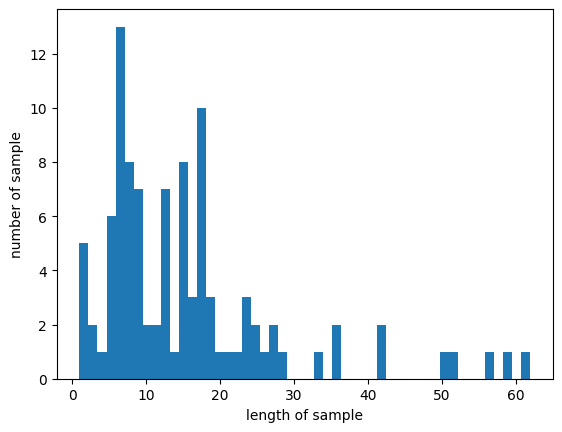

In [70]:
max_len = max(len(l) for l in encoded)
print('리뷰의 최대 길이 : %d' % max_len)
print('리뷰의 최소 길이 : %d' % min(len(l) for l in encoded))
print('리뷰의 평균 길이 : %f' % (sum(map(len, encoded))/len(encoded)))
plt.hist([len(s) for s in encoded], bins=50)
plt.xlabel('length of sample')
plt.ylabel('number of sample')
plt.show() #리뷰 길이 분포를

In [64]:
for line in encoded:
  if len(line) < max_len:
    line += [word2index['pad']] * (max_len - len(line))  #가장 긴 문장 기준으로, 패딩 넣어서 문장길이 맞춤

In [73]:
print('리뷰의 최대 길이 : %d' % max(len(l) for l in encoded))
print('리뷰의 최소 길이 : %d' % min(len(l) for l in encoded))
print('리뷰의 평균 길이 : %f' % (sum(map(len, encoded))/len(encoded)))

리뷰의 최대 길이 : 62
리뷰의 최소 길이 : 1
리뷰의 평균 길이 : 15.610000


In [74]:
print(encoded[:2])
# 단어들을 고유한 정수로 매핑 완료.
# 각 정수를 고유한 단어 벡터로 바꾸는 작업(원핫 인코딩 / 워드 임베딩)이 필요함

[[84, 32, 10, 5, 54, 46, 85, 18, 33, 34], [201, 6, 86, 202, 19, 203, 204, 55, 205, 122, 6, 206, 207, 24, 123, 208, 209, 15, 2, 56, 87, 124, 35, 55, 210, 125, 126, 36, 211, 6, 212, 213, 20, 122, 8, 57, 58, 20, 47, 214, 6, 215, 5, 216, 16, 8, 88, 37, 217, 89, 2]]
